In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Clone repo and install utils
!git clone https://github.com/ab126/fmri_forecasting.git
import sys
sys.path.insert(0, "/content/fmri_forecasting")

Cloning into 'fmri_forecasting'...
remote: Enumerating objects: 64, done.
remote: Counting objects: 100% (64/64), done.
remote: Compressing objects: 100% (45/45), done.
remote: Total 64 (delta 23), reused 56 (delta 15), pack-reused 0 (from 0)
Receiving objects: 100% (64/64), 591.48 KiB | 5.58 MiB/s, done.
Resolving deltas: 100% (23/23), done.


In [3]:
# =========================
# STEP 1: IMPORTS
# =========================

import os
import numpy as np
from collections import Counter

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt
import pandas as pd
from tqdm.auto import tqdm

# Utils — imported from repo
from utils.parse_data import (
    load_dataset,
    normalize_items,
    build_sliding_windows,
    split_by_subject,
    load_dataset_main
)
from utils.training import (
    FMRIWindowDataset,
    DeltaAwareLoss,
    train_model,
    get_predictions,
    compute_rmse,
    compute_naive_rmse,
    compute_eta,
    horizon_rmse,
    run_loso_cv
)
from utils.plotting import (
    plot_single_roi_prediction,
    show_individual_roi_results
)

In [6]:
# =========================
# STEP 3: DATASET INITIALIZATION
# =========================

from google.colab import drive
import time

drive.mount("/content/drive")

# Drive'dan local'e kopyala
drive_root = "/content/drive/MyDrive/PROJE_FMRI/Copy of pooled_stratified_share/pooled_stratified_share"
local_root = "/content/pooled_stratified_share"

print("Copying dataset from Drive...")
start = time.time()
!rm -rf /content/pooled_stratified_share
!cp -r "{drive_root}" /content/
print(f"Copy done in {time.time()-start:.1f}s")

# load_dataset_main() data/pooled_stratified_share yoluna bakıyor
# Colab'da symlink oluştur
!mkdir -p /content/fmri_forecasting/data
!ln -sfn /content/pooled_stratified_share \
         /content/fmri_forecasting/data/pooled_stratified_share

# Dataset yükle
import os
os.chdir("/content/fmri_forecasting")   # working dir repo'ya al

dataset, device = load_dataset_main()
print(f"Loaded: {len(dataset)} runs | Device: {device}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Copying dataset from Drive...
Copy done in 548.9s
Using dataset path: data/pooled_stratified_share
Loading dataset with fixed schema settings...
Scanning and loading dataset (optimized fixed schema mode)...
Loaded: 2144 runs from 6 subjects
Subjects: ['subjOenz4SHyaO', 'subjQX6R7rImeb', 'subjoVC0sHUB_P', 'subjqFdsBbuiHF', 'subjtySNgRhV65', 'subjxpYwO4azeZ']
Successfully loaded runs: 2144
Loading time: 1.71 seconds
Device: cuda
Loaded: 2144 runs | Device: cuda


In [7]:
# =========================
# STEP 6: ADVANCED LSTM MODEL
# =========================

class AdvancedLSTM(nn.Module):
    """
    Multi-layer LSTM for multi-step fMRI BOLD forecasting.
    Takes a sequence of M past ROI vectors and predicts H future steps.
    """

    def __init__(self, input_size, hidden_size=512, num_layers=3,
                 output_horizon=5, dropout=0.5):
        super().__init__()

        self.output_horizon = output_horizon
        self.input_size     = input_size

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )

        self.fc = nn.Linear(hidden_size, output_horizon * input_size)

    def forward(self, x):
        _, (h_n, _) = self.lstm(x)
        last_h = h_n[-1]
        out    = self.fc(last_h)
        return out.view(-1, self.output_horizon, self.input_size)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


In [9]:
# =========================
# STEP 10: RUN LOSO-CV
# =========================

M, H = 50, 3

def model_gen():
    """Returns a fresh AdvancedLSTM instance for each fold."""
    return AdvancedLSTM(
        input_size=19,
        hidden_size=512,
        output_horizon=H,
        dropout=0.5
    )

results_df, model, X_test, Y_test, \
best_model, best_X_test, best_Y_test = run_loso_cv(
    dataset_raw=dataset,
    model_gen=model_gen,
    M=M,
    H=H,
    stride=1,
    num_epochs=20,
    batch_size=512,
    device=device
)


LOSO-CV | 6 subjects | M=50, H=3


LOSO Folds:   0%|          | 0/6 [00:00<?, ?it/s]


Fold 1/6 | Test subject: subjOenz4SHyaO
Train subjects: ['subjQX6R7rImeb', 'subjoVC0sHUB_P', 'subjqFdsBbuiHF', 'subjtySNgRhV65', 'subjxpYwO4azeZ']
Test subjects : ['subjOenz4SHyaO']
Train runs: 1744
Test runs : 400
Train windows: 273110 | Val windows: 30346 | Test windows: 69600 | ROIs: 19
Training (max 20 epochs, early stopping patience=5)...


Epoch 1/20:   0%|          | 0/534 [00:00<?, ?it/s]

  Epoch  1 | train: 0.282655 | val: 0.283871


...

  Epoch  8 | train: 0.250354 | val: 0.270675
  No improvement (3/5)


Epoch 9/20:   0%|          | 0/534 [00:00<?, ?it/s]

  Epoch  9 | train: 0.248469 | val: 0.272192
  No improvement (4/5)


Epoch 10/20:   0%|          | 0/534 [00:00<?, ?it/s]

  Epoch 10 | train: 0.246483 | val: 0.273052
  No improvement (5/5)
  Early stopping at epoch 10
  Best val loss: 0.268726 — weights restored

Results:
  LSTM RMSE  : 0.814925
  Naive RMSE : 1.023983
  eta        : 0.1212
  Beat naive : YES

Horizon-wise RMSE:
  Step 1 RMSE: 0.715518
  Step 2 RMSE: 0.842516
  Step 3 RMSE: 0.877785

LOSO-CV SUMMARY
  test_subject  LSTM_RMSE  Naive_RMSE    eta  beat_naive
subjOenz4SHyaO   0.819327    1.025474 0.1114        True
subjQX6R7rImeb   0.784229    0.946010 0.1328        True
subjoVC0sHUB_P   0.812352    0.969542 0.1231        True
subjqFdsBbuiHF   0.866448    1.120833 0.0848        True
subjtySNgRhV65   0.851799    1.055014 0.0934        True
subjxpYwO4azeZ   0.814925    1.023983 0.1212        True

Mean LSTM RMSE  : 0.824847
Mean Naive RMSE : 1.023476
Mean eta        : 0.1111
Folds beat naive: 6 / 6

Results saved to loso_results.csv

Best eta fold : subjQX6R7rImeb (η=0.1328)



FINAL MODEL VISUALIZATION (INDIVIDUAL ROIs)
Using test sample index: 32268

ROI 0


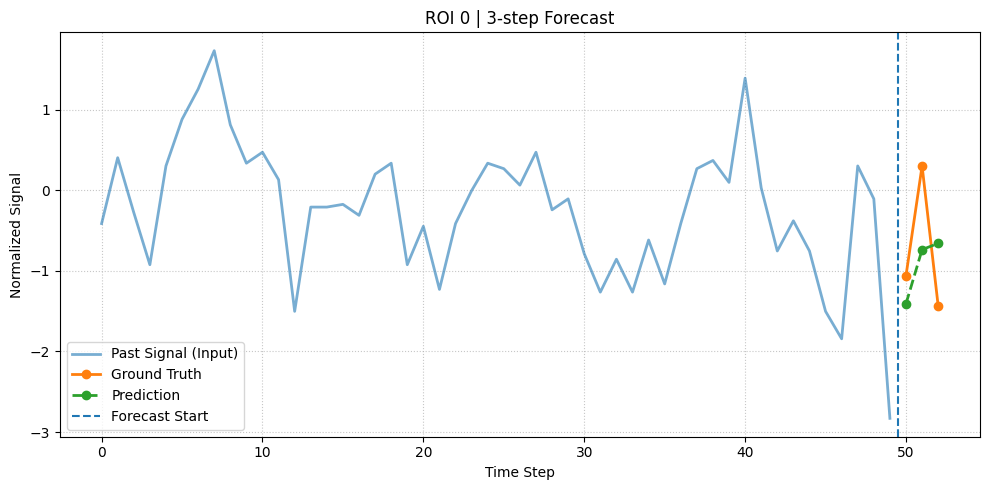


ROI 3


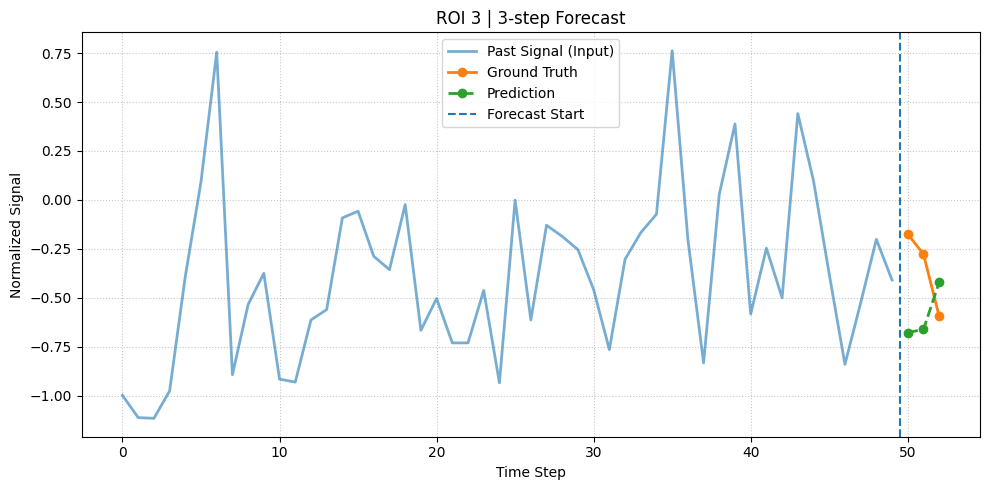


ROI 7


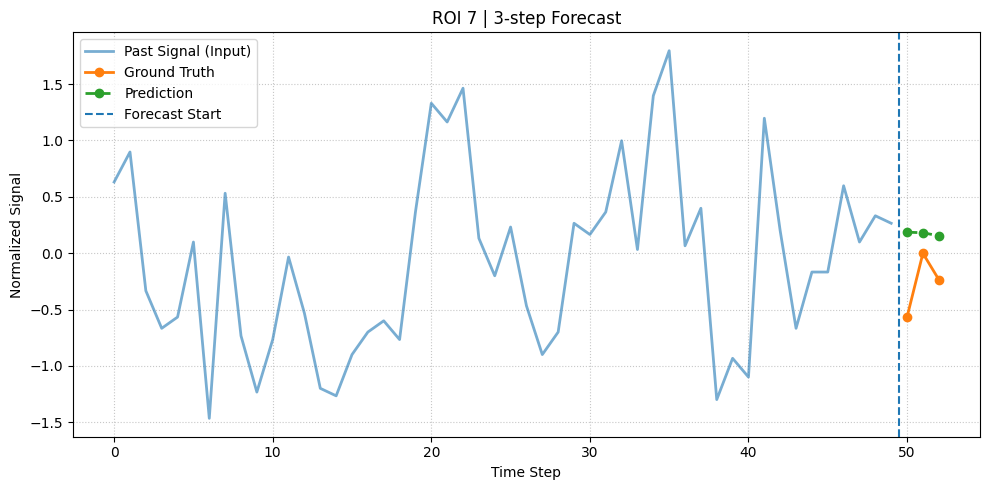

In [10]:
# =========================
# STEP 11: FINAL VISUALIZATION (INDIVIDUAL ROI PLOTS)
# (FIXED: align_mean=False — mean-shifting hides true prediction error)
# =========================

import matplotlib.pyplot as plt
import numpy as np
import torch


def plot_single_roi_prediction(model, X_test, Y_test, device,
                                roi_idx=0, sample_idx=None,
                                align_mean=False):
    """
    Plot prediction vs ground truth for a single ROI.

    align_mean: if True, shifts predictions to match ground truth mean.
                WARNING: this artificially improves the visual appearance
                and should NOT be used when reporting results.
                Keep False for honest evaluation plots.
    """

    model.eval()

    if sample_idx is None:
        sample_idx = np.random.randint(len(X_test))

    with torch.no_grad():
        sample_x = torch.tensor(
            X_test[sample_idx:sample_idx + 1],
            dtype=torch.float32
        ).to(device)

        sample_y = Y_test[sample_idx]
        pred_y   = model(sample_x).cpu().numpy()[0]

        if align_mean:
            # Mean alignment: for exploration only, not for reporting
            print("WARNING: align_mean=True is enabled — plot is for exploration only.")
            pred_y = pred_y - pred_y.mean(axis=0) + sample_y.mean(axis=0)

    past_time   = np.arange(X_test.shape[1])
    future_time = np.arange(X_test.shape[1], X_test.shape[1] + Y_test.shape[1])

    plt.figure(figsize=(10, 5))

    plt.plot(past_time, X_test[sample_idx, :, roi_idx],
             label="Past Signal (Input)", linewidth=2, alpha=0.6)

    plt.plot(future_time, sample_y[:, roi_idx],
             "o-", label="Ground Truth", linewidth=2)

    plt.plot(future_time, pred_y[:, roi_idx],
             "o--", label="Prediction", linewidth=2)

    plt.axvline(x=X_test.shape[1] - 0.5, linestyle="--", label="Forecast Start")

    plt.title(f"ROI {roi_idx} | {Y_test.shape[1]}-step Forecast")
    plt.xlabel("Time Step")
    plt.ylabel("Normalized Signal")
    plt.legend()
    plt.grid(True, linestyle=":", alpha=0.7)
    plt.tight_layout()
    plt.show()


def show_individual_roi_results(model, X_test, Y_test, device,
                                 roi_list=None, sample_idx=None):
    """
    Show separate prediction plots for each ROI in roi_list.
    Defaults to first 3 ROIs if roi_list is not provided.
    """

    if roi_list is None:
        n_roi = X_test.shape[2]
        roi_list = list(range(min(3, n_roi)))

    print("\nFINAL MODEL VISUALIZATION (INDIVIDUAL ROIs)")
    print("=" * 50)

    if sample_idx is None:
        sample_idx = np.random.randint(len(X_test))

    print(f"Using test sample index: {sample_idx}")

    for roi in roi_list:
        print(f"\nROI {roi}")
        plot_single_roi_prediction(
            model=model,
            X_test=X_test,
            Y_test=Y_test,
            device=device,
            roi_idx=roi,
            sample_idx=sample_idx,
            align_mean=False    # keep False for honest plots
        )


# =========================
# DIRECT OUTPUT
# =========================

show_individual_roi_results(
    model=model,
    X_test=X_test,
    Y_test=Y_test,
    device=device,
    roi_list=[0, 3, 7],
    sample_idx=None
)



Best sample idx: 372, Best ROI: 14, RMSE: 0.0243


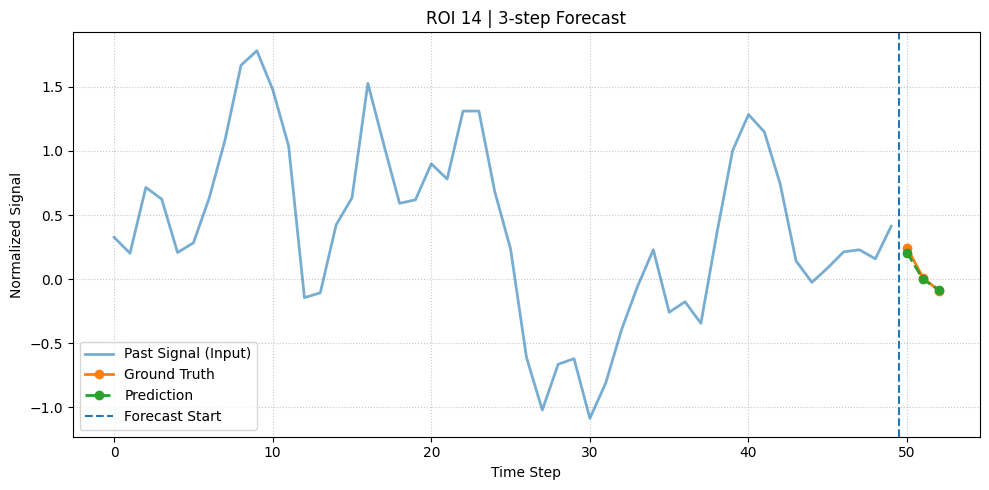

In [12]:
# Find best predicted sample AND best ROI
sample_idx = None
best_roi = None
best_err = float('inf')
model.eval()

with torch.no_grad():
    for i in range(min(500, len(X_test))):
        x = torch.tensor(X_test[i:i+1]).to(device)
        p = model(x).cpu().numpy()[0]
        for roi in range(X_test.shape[2]):
            err = np.sqrt(np.mean((Y_test[i, :, roi] - p[:, roi])**2))
            if err < best_err:
                best_err = err
                sample_idx = i
                best_roi = roi

print(f"Best sample idx: {sample_idx}, Best ROI: {best_roi}, RMSE: {best_err:.4f}")

plot_single_roi_prediction(
    model=model,
    X_test=X_test,
    Y_test=Y_test,
    device=device,
    roi_idx=best_roi,
    sample_idx=sample_idx,
    align_mean=False
)
plt.show()

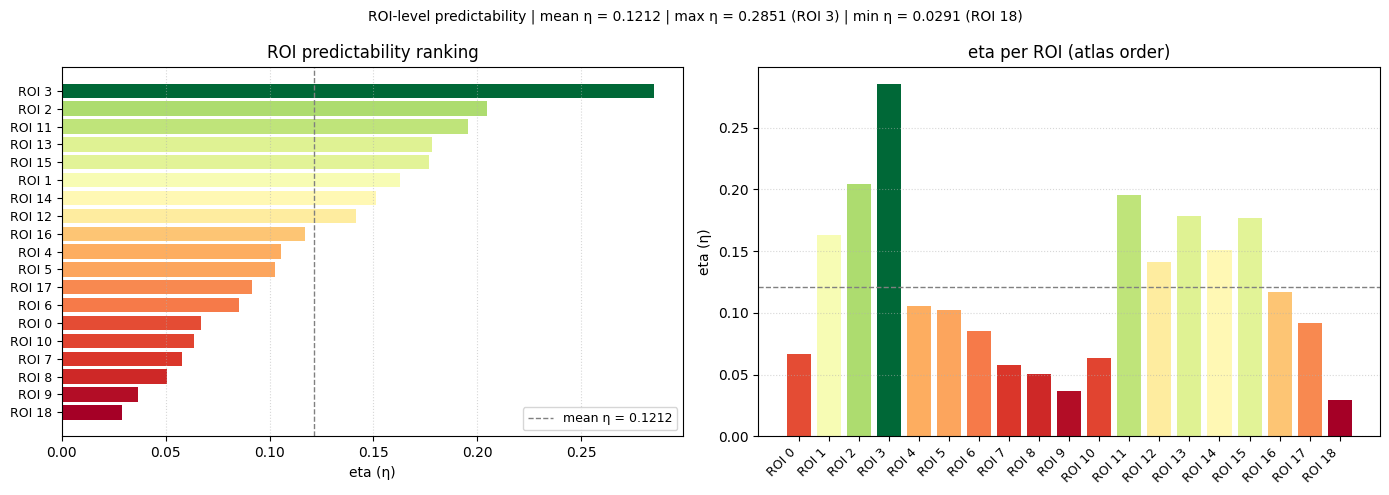


ROI-level eta summary:
ROI             eta    rank
----------------------------
ROI 3        0.2851       1
ROI 2        0.2048       2
ROI 11       0.1956       3
ROI 13       0.1782       4
ROI 15       0.1768       5
ROI 1        0.1629       6
ROI 14       0.1513       7
ROI 12       0.1415       8
ROI 16       0.1172       9
ROI 4        0.1055      10
ROI 5        0.1026      11
ROI 17       0.0914      12
ROI 6        0.0854      13
ROI 0        0.0670      14
ROI 10       0.0637      15
ROI 7        0.0577      16
ROI 8        0.0504      17
ROI 9        0.0367      18
ROI 18       0.0291      19

Most predictable  : ROI 3 (η=0.2851)
Least predictable : ROI 18 (η=0.0291)
Mean eta          : 0.1212
Std eta           : 0.0659


In [13]:
# =========================
# STEP 13: ROI-LEVEL ETA ANALYSIS
# Which brain regions are most predictable?
# =========================

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import torch

def compute_eta_per_roi(y_true, y_pred):
    """
    Compute information-theoretic eta separately for each ROI.

    η_roi = I(Y_roi; Ŷ_roi) / H(Y_roi)

    Returns:
        eta_per_roi : (n_roi,) array
    """
    if y_true.ndim == 3:
        y_true = y_true.reshape(-1, y_true.shape[-1])
        y_pred = y_pred.reshape(-1, y_pred.shape[-1])

    n_roi = y_true.shape[1]
    etas  = []

    for roi in range(n_roi):
        yt = y_true[:, roi]
        yp = y_pred[:, roi]

        if yt.std() < 1e-8 or yp.std() < 1e-8:
            etas.append(0.0)
            continue

        r = np.corrcoef(yt, yp)[0, 1]
        r = np.clip(r, -1 + 1e-7, 1 - 1e-7)

        mi = -0.5 * np.log(1 - r ** 2)
        hy =  0.5 * np.log(2 * np.pi * np.e * (yt.var() + 1e-12))
        etas.append(float(mi / (hy + 1e-12)))

    return np.array(etas)


def run_roi_eta_analysis(model, X_test, Y_test, device,
                          roi_labels=None):
    """
    Compute per-ROI eta and visualize as a ranked bar chart.

    roi_labels : list of ROI names (e.g. ['V1', 'V2', ...])
                 if None, uses ROI indices.
    """
    # Get predictions
    all_preds, all_targets = get_predictions(model,
        DataLoader(FMRIWindowDataset(X_test, Y_test),
                   batch_size=512, shuffle=False),
        device)

    eta_per_roi = compute_eta_per_roi(all_targets, all_preds)
    n_roi = len(eta_per_roi)

    if roi_labels is None:
        roi_labels = [f"ROI {i}" for i in range(n_roi)]

    # Sort by eta descending
    sorted_idx  = np.argsort(eta_per_roi)[::-1]
    sorted_eta  = eta_per_roi[sorted_idx]
    sorted_labels = [roi_labels[i] for i in sorted_idx]

    # --- Plot ---
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Left: ranked bar chart
    colors = cm.RdYlGn(
        (sorted_eta - sorted_eta.min()) /
        (sorted_eta.max() - sorted_eta.min() + 1e-8)
    )
    axes[0].barh(range(n_roi), sorted_eta[::-1],
                 color=colors[::-1])
    axes[0].set_yticks(range(n_roi))
    axes[0].set_yticklabels(sorted_labels[::-1], fontsize=9)
    axes[0].set_xlabel("eta (η)")
    axes[0].set_title("ROI predictability ranking")
    axes[0].axvline(x=eta_per_roi.mean(), color='gray',
                    linestyle='--', linewidth=1,
                    label=f"mean η = {eta_per_roi.mean():.4f}")
    axes[0].legend(fontsize=9)
    axes[0].grid(axis='x', linestyle=':', alpha=0.5)

    # Right: raw bar chart in ROI order
    roi_colors = cm.RdYlGn(
        (eta_per_roi - eta_per_roi.min()) /
        (eta_per_roi.max() - eta_per_roi.min() + 1e-8)
    )
    axes[1].bar(range(n_roi), eta_per_roi, color=roi_colors)
    axes[1].set_xticks(range(n_roi))
    axes[1].set_xticklabels(roi_labels, rotation=45,
                             ha='right', fontsize=9)
    axes[1].set_ylabel("eta (η)")
    axes[1].set_title("eta per ROI (atlas order)")
    axes[1].axhline(y=eta_per_roi.mean(), color='gray',
                    linestyle='--', linewidth=1)
    axes[1].grid(axis='y', linestyle=':', alpha=0.5)

    plt.suptitle(
        f"ROI-level predictability | mean η = {eta_per_roi.mean():.4f} "
        f"| max η = {sorted_eta[0]:.4f} ({sorted_labels[0]}) "
        f"| min η = {sorted_eta[-1]:.4f} ({sorted_labels[-1]})",
        fontsize=10
    )
    plt.tight_layout()
    plt.show()

    # Print summary table
    print("\nROI-level eta summary:")
    print(f"{'ROI':<10} {'eta':>8}  {'rank':>6}")
    print("-" * 28)
    for rank, idx in enumerate(sorted_idx):
        print(f"{roi_labels[idx]:<10} {eta_per_roi[idx]:>8.4f}  {rank+1:>6}")

    print(f"\nMost predictable  : {sorted_labels[0]} (η={sorted_eta[0]:.4f})")
    print(f"Least predictable : {sorted_labels[-1]} (η={sorted_eta[-1]:.4f})")
    print(f"Mean eta          : {eta_per_roi.mean():.4f}")
    print(f"Std eta           : {eta_per_roi.std():.4f}")

    return eta_per_roi, sorted_idx


# =========================
# RUN
# =========================

# If you have ROI label names from the atlas, pass them here
# roi_labels = list(dataset[0]["roi_labels"])  # uncomment if available

eta_per_roi, sorted_idx = run_roi_eta_analysis(
    model=model,
    X_test=X_test,
    Y_test=Y_test,
    device=device,
    roi_labels=None    # or roi_labels=roi_labels
)

In [22]:
%%writefile LSTM_model_library_Sklearn.py
import torch
import torch.nn as nn
import numpy as np
from sklearn.base import BaseEstimator, RegressorMixin
from torch.utils.data import Dataset, DataLoader


class FMRIWindowDataset(Dataset):
    """PyTorch dataset for fMRI windowed sequences."""

    def __init__(self, X, Y=None):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.Y = None
        if Y is not None:
            self.Y = torch.tensor(Y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        if self.Y is not None:
            return self.X[idx], self.Y[idx]
        return self.X[idx]


class AdvancedLSTM(nn.Module):
    """
    Multi-layer LSTM for multi-step fMRI BOLD forecasting.
    Takes a sequence of M past ROI vectors and predicts H future steps.
    """
    def __init__(self, input_size, hidden_size=512, num_layers=3,
                 output_horizon=5, dropout=0.5):
        super().__init__()
        self.output_horizon = output_horizon
        self.input_size     = input_size
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )
        self.fc = nn.Linear(hidden_size, output_horizon * input_size)

    def forward(self, x):
        _, (h_n, _) = self.lstm(x)
        last_h = h_n[-1]
        out    = self.fc(last_h)
        return out.view(-1, self.output_horizon, self.input_size)


class FmriPredictorAPI(BaseEstimator, RegressorMixin):
    """
    Scikit-Learn compatible API for the fMRI LSTM model.

    Methods:
        predict(X)            — point prediction: x̂_t = argmax p̂(x_t|past)
        calibrate(X_cal,Y_cal)— estimate per-ROI residual std for proba
        predict_proba(X)      — returns (mean, std) of p̂(x_t|past) ~ N(μ,σ²)
        log_prob(X, Y)        — log p̂(y_t|past) under Gaussian assumption
    """

    def __init__(self, model_obj=None, M=50, H=5, device='cpu',
                 roi_std=None):
        self.model_obj = model_obj
        self.M         = M
        self.H         = H
        self.device    = device
        self.roi_std   = roi_std

        if self.model_obj is not None:
            self.model_obj.to(self.device)
            self.model_obj.eval()

    def fit(self, X, y=None):
        """Exists for Scikit-Learn compatibility. No training performed here."""
        return self

    def _run_inference(self, X, batch_size=512):
        """Shared inference loop."""
        if self.model_obj is None:
            raise ValueError("Model object is not initialized.")

        self.model_obj.eval()

        # Fix RNN contiguous memory warning
        if hasattr(self.model_obj, 'lstm'):
            self.model_obj.lstm.flatten_parameters()

        loader = DataLoader(
            FMRIWindowDataset(X),
            batch_size=batch_size,
            shuffle=False,
            pin_memory=True
        )
        preds = []
        with torch.no_grad():
            for x_batch in loader:
                x_batch = x_batch.to(self.device)
                preds.append(self.model_obj(x_batch).cpu().numpy())
        return np.concatenate(preds, axis=0)

    def predict(self, X, batch_size=512):
        """
        Point prediction: x̂_t = argmax_x p̂(x_t | past)
        Under Gaussian assumption this equals the mean.

        Input  X : (N, M, ROI)
        Output Y : (N, H, ROI)
        """
        return self._run_inference(X, batch_size)

    def calibrate(self, X_cal, Y_cal, batch_size=512):
        """
        Estimate per-ROI residual std from a calibration set.
        Must be called once before predict_proba or log_prob.

        X_cal : (N, M, ROI) — calibration inputs
        Y_cal : (N, H, ROI) — corresponding ground truth
        """
        Y_pred     = self.predict(X_cal, batch_size)
        residuals  = Y_cal - Y_pred
        flat       = residuals.reshape(-1, residuals.shape[-1])
        self.roi_std = flat.std(axis=0) + 1e-8
        print(f"Calibration done. Per-ROI std shape : {self.roi_std.shape}")
        print(f"Mean std across ROIs                : {self.roi_std.mean():.4f}")
        return self

    def predict_proba(self, X, batch_size=512):
        """
        Probabilistic prediction: p̂(x_t | past) ~ N(mean, std²)

        mean = LSTM point prediction
        std  = per-ROI residual std from calibrate()

        Input  X    : (N, M, ROI)
        Output mean : (N, H, ROI)
               std  : (N, H, ROI)
        """
        if self.roi_std is None:
            raise ValueError(
                "roi_std not set. Run calibrate(X_cal, Y_cal) first."
            )
        mean = self.predict(X, batch_size)
        std  = np.broadcast_to(
            self.roi_std[np.newaxis, np.newaxis, :],
            mean.shape
        ).copy()
        return mean, std

    def log_prob(self, X, Y, batch_size=512):
        """
        Compute log p̂(y_t | past) under Gaussian assumption.

        log p̂(x_t|past) = -0.5*((x_t - μ_t)²/σ²) - log(σ√2π)

        Input  X     : (N, M, ROI)
               Y     : (N, H, ROI)
        Output log_p : (N, H, ROI)
        """
        mean, std = self.predict_proba(X, batch_size)
        log_p = (
            -0.5 * ((Y - mean) ** 2) / (std ** 2)
            - np.log(std * np.sqrt(2 * np.pi))
        )
        return log_p

    def get_params(self, deep=True):
        return dict(model_obj=self.model_obj, M=self.M, H=self.H,
                    device=self.device, roi_std=self.roi_std)

    def set_params(self, **params):
        for k, v in params.items():
            setattr(self, k, v)
        return self

Writing LSTM_model_library_Sklearn.py


In [23]:
import joblib
import importlib
import LSTM_model_library_Sklearn
import shutil

# Refresh module
importlib.reload(LSTM_model_library_Sklearn)
from LSTM_model_library_Sklearn import FmriPredictorAPI

# 1. Wrap best model
fmri_sklearn_api = FmriPredictorAPI(
    model_obj=best_model,
    M=50,
    H=3,
    device=device
)

# 2. Calibrate — estimate per-ROI std from test residuals
fmri_sklearn_api.calibrate(best_X_test, best_Y_test)

# 3. Save
model_filename = "best_fmri_sklearn_api.joblib"
joblib.dump(fmri_sklearn_api, model_filename)
print(f"Model '{model_filename}' successfully saved.")

# 4. Load and verify
loaded_fmri_sklearn_api = joblib.load(model_filename)
print(f"Model '{model_filename}' successfully loaded.")

# 5. Quick verify
mean, std = loaded_fmri_sklearn_api.predict_proba(best_X_test[:5])
print(f"\npredict_proba check:")
print(f"  mean shape : {mean.shape}")
print(f"  std  shape : {std.shape}")

# 6. Save to Drive
shutil.copy("best_fmri_sklearn_api.joblib",
            "/content/drive/MyDrive/PROJE_FMRI/best_fmri_sklearn_api.joblib")
shutil.copy("LSTM_model_library_Sklearn.py",
            "/content/drive/MyDrive/PROJE_FMRI/LSTM_model_library_Sklearn.py")
print("Both files saved to Drive.")

Calibration done. Per-ROI std shape : (19,)
Mean std across ROIs                : 0.7649
Model 'best_fmri_sklearn_api.joblib' successfully saved.
Model 'best_fmri_sklearn_api.joblib' successfully loaded.

predict_proba check:
  mean shape : (5, 3, 19)
  std  shape : (5, 3, 19)
Both files saved to Drive.


PART A: PROBABILISTIC FORECAST


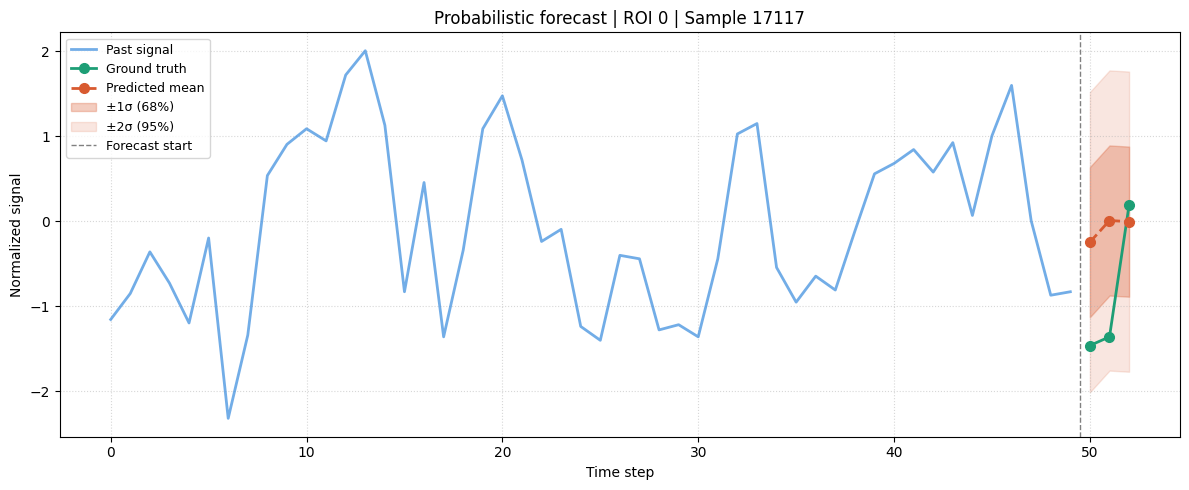

ROI 0 | Sample 17117
  Predicted mean : [-0.24722376  0.00750413 -0.00597771]
  Ground truth   : [-1.4639014  -1.3618412   0.18948868]
  Sigma          : 0.8834
  Coverage 1σ    : 33%  (expected 68%)
  Coverage 2σ    : 100%  (expected 95%)

Calibration check across all ROIs:


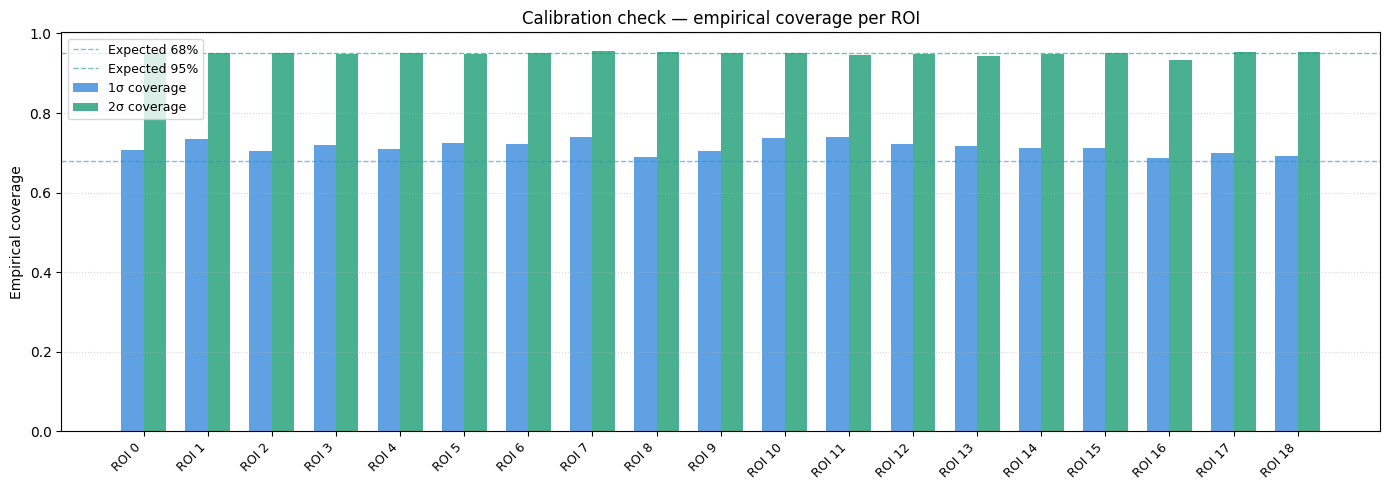


Mean 1σ coverage : 71.5%  (expected 68%)
Mean 2σ coverage : 94.9%  (expected 95%)
  → Reasonably CALIBRATED

PART B: MODEL-BASED MUTUAL INFORMATION


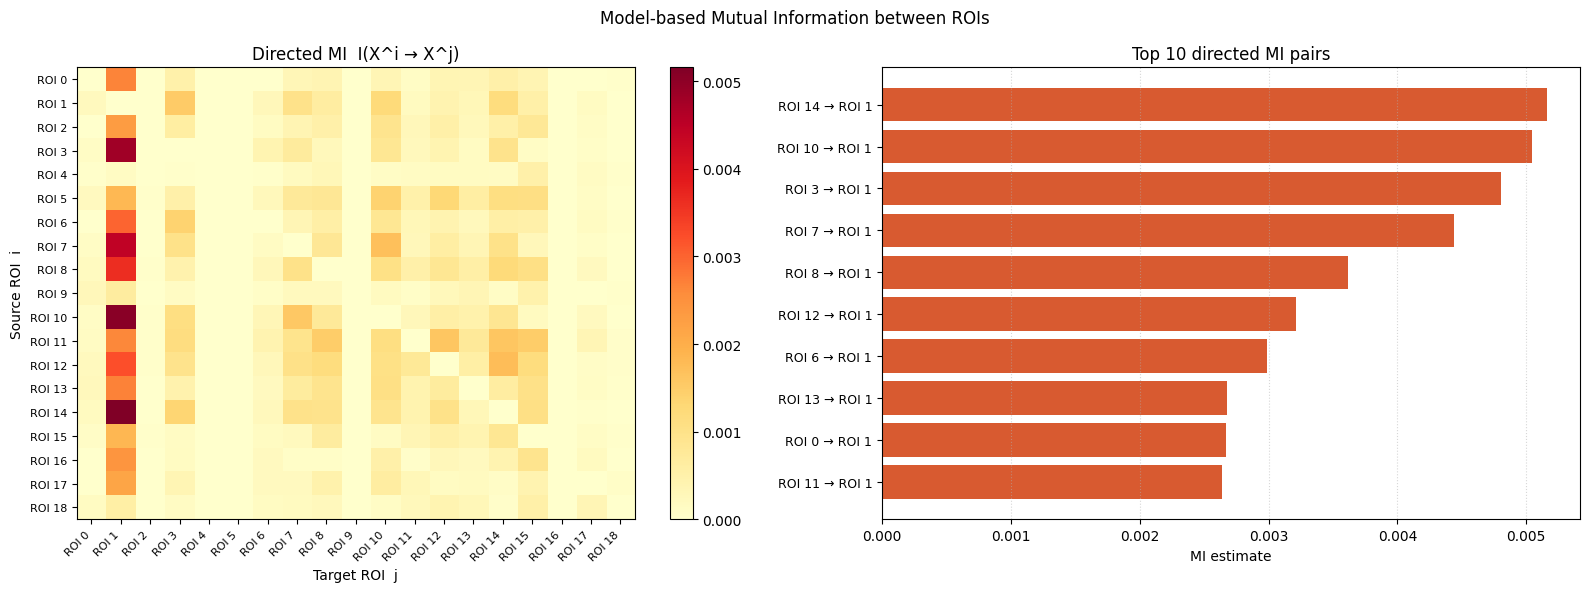


Top 10 directed connections:
  ROI 14 → ROI  1 : MI = 0.0052
  ROI 10 → ROI  1 : MI = 0.0050
  ROI  3 → ROI  1 : MI = 0.0048
  ROI  7 → ROI  1 : MI = 0.0044
  ROI  8 → ROI  1 : MI = 0.0036
  ROI 12 → ROI  1 : MI = 0.0032
  ROI  6 → ROI  1 : MI = 0.0030
  ROI 13 → ROI  1 : MI = 0.0027
  ROI  0 → ROI  1 : MI = 0.0027
  ROI 11 → ROI  1 : MI = 0.0026

MI matrix summary:
  Max MI                : ROI 14 → ROI 1 = 0.0052
  Mean MI (off-diagonal): 0.0005


In [24]:
import numpy as np
import matplotlib.pyplot as plt


def plot_probabilistic_forecast(api, X_test, Y_test,
                                 sample_idx=None, roi_idx=0):
    """Plot forecast mean + 1σ/2σ confidence intervals for one sample."""
    if sample_idx is None:
        sample_idx = np.random.randint(len(X_test))

    mean, std = api.predict_proba(X_test[sample_idx:sample_idx+1])
    mean, std = mean[0], std[0]

    past   = X_test[sample_idx, :, roi_idx]
    future = Y_test[sample_idx, :, roi_idx]
    mu     = mean[:, roi_idx]
    sigma  = std[:, roi_idx]

    M, H = len(past), len(future)
    past_time   = np.arange(M)
    future_time = np.arange(M, M + H)

    plt.figure(figsize=(12, 5))
    plt.plot(past_time, past,
             color="#378ADD", linewidth=2, alpha=0.7,
             label="Past signal")
    plt.plot(future_time, future,
             "o-", color="#1D9E75", linewidth=2, markersize=7,
             label="Ground truth")
    plt.plot(future_time, mu,
             "o--", color="#D85A30", linewidth=2, markersize=7,
             label="Predicted mean")
    plt.fill_between(future_time, mu - sigma, mu + sigma,
                     alpha=0.3, color="#D85A30", label="±1σ (68%)")
    plt.fill_between(future_time, mu - 2*sigma, mu + 2*sigma,
                     alpha=0.15, color="#D85A30", label="±2σ (95%)")
    plt.axvline(x=M - 0.5, linestyle="--", color="gray",
                linewidth=1, label="Forecast start")
    plt.title(f"Probabilistic forecast | ROI {roi_idx} | Sample {sample_idx}")
    plt.xlabel("Time step")
    plt.ylabel("Normalized signal")
    plt.legend(fontsize=9)
    plt.grid(True, linestyle=":", alpha=0.5)
    plt.tight_layout()
    plt.show()

    in_1s = np.mean(np.abs(future - mu) < sigma)
    in_2s = np.mean(np.abs(future - mu) < 2 * sigma)
    print(f"ROI {roi_idx} | Sample {sample_idx}")
    print(f"  Predicted mean : {mu}")
    print(f"  Ground truth   : {future}")
    print(f"  Sigma          : {sigma[0]:.4f}")
    print(f"  Coverage 1σ    : {in_1s*100:.0f}%  (expected 68%)")
    print(f"  Coverage 2σ    : {in_2s*100:.0f}%  (expected 95%)")


def plot_all_roi_coverage(api, X_test, Y_test):
    """Per-ROI 1σ and 2σ coverage to check model calibration."""
    mean, std = api.predict_proba(X_test)
    n_roi = X_test.shape[2]

    cov_1, cov_2 = [], []
    for roi in range(n_roi):
        y  = Y_test[:, :, roi].flatten()
        mu = mean[:, :, roi].flatten()
        sg = std[:, :, roi].flatten()
        cov_1.append(np.mean(np.abs(y - mu) < sg))
        cov_2.append(np.mean(np.abs(y - mu) < 2*sg))

    x = np.arange(n_roi)
    w = 0.35
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.bar(x - w/2, cov_1, w, label="1σ coverage",
           color="#378ADD", alpha=0.8)
    ax.bar(x + w/2, cov_2, w, label="2σ coverage",
           color="#1D9E75", alpha=0.8)
    ax.axhline(0.68, color="#378ADD", linestyle="--",
               linewidth=1, alpha=0.6, label="Expected 68%")
    ax.axhline(0.95, color="#1D9E75", linestyle="--",
               linewidth=1, alpha=0.6, label="Expected 95%")
    ax.set_xticks(x)
    ax.set_xticklabels([f"ROI {i}" for i in range(n_roi)],
                        rotation=45, ha="right", fontsize=9)
    ax.set_ylabel("Empirical coverage")
    ax.set_title("Calibration check — empirical coverage per ROI")
    ax.legend(fontsize=9)
    ax.grid(axis="y", linestyle=":", alpha=0.5)
    plt.tight_layout()
    plt.show()

    m1, m2 = np.mean(cov_1), np.mean(cov_2)
    print(f"\nMean 1σ coverage : {m1*100:.1f}%  (expected 68%)")
    print(f"Mean 2σ coverage : {m2*100:.1f}%  (expected 95%)")
    if m1 > 0.80:
        print("  → UNDERCONFIDENT (intervals too wide)")
    elif m1 < 0.55:
        print("  → OVERCONFIDENT (intervals too narrow)")
    else:
        print("  → Reasonably CALIBRATED")

    return cov_1, cov_2


def compute_mi_matrix(api, X_test, Y_test, batch_size=512):
    """
    Model-based directed MI estimator (Slide 2):
        I(X^i → X^j) ≈ E[ log p̂_full(x^j) / p̂_reduced(x^j) ]
                         × |corr(μ^i, μ^j)|
    """
    mean_full, sigma = api.predict_proba(X_test, batch_size)
    n_roi   = X_test.shape[2]
    Y_flat  = Y_test.reshape(-1, n_roi)
    mu_flat = mean_full.reshape(-1, n_roi)
    sg_flat = sigma.reshape(-1, n_roi)
    sg_marg = Y_flat.std(axis=0) + 1e-8

    log_ratio = (
        0.5 * (Y_flat ** 2) / (sg_marg ** 2)
        - 0.5 * ((Y_flat - mu_flat) ** 2) / (sg_flat ** 2)
    )

    mi_matrix = np.zeros((n_roi, n_roi))
    for j in range(n_roi):
        improvement_j = log_ratio[:, j]
        for i in range(n_roi):
            if i == j:
                continue
            r = np.corrcoef(mu_flat[:, i], mu_flat[:, j])[0, 1]
            r = np.clip(abs(r), 0, 1 - 1e-7)
            mi_matrix[i, j] = max(np.mean(improvement_j) * r, 0)

    return mi_matrix


def plot_mi_matrix(mi_matrix, roi_labels=None):
    """MI heatmap + top 10 directed connections."""
    n_roi = mi_matrix.shape[0]
    if roi_labels is None:
        roi_labels = [f"ROI {i}" for i in range(n_roi)]

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    im = axes[0].imshow(mi_matrix, cmap="YlOrRd", aspect="auto")
    axes[0].set_xticks(range(n_roi))
    axes[0].set_yticks(range(n_roi))
    axes[0].set_xticklabels(roi_labels, rotation=45,
                             ha="right", fontsize=8)
    axes[0].set_yticklabels(roi_labels, fontsize=8)
    axes[0].set_title("Directed MI  I(X^i → X^j)")
    axes[0].set_xlabel("Target ROI  j")
    axes[0].set_ylabel("Source ROI  i")
    plt.colorbar(im, ax=axes[0])

    pairs = [(mi_matrix[i, j], i, j)
             for i in range(n_roi)
             for j in range(n_roi) if i != j]
    pairs.sort(reverse=True)
    top_n = 10
    top_vals   = [p[0] for p in pairs[:top_n]]
    top_labels = [f"ROI {p[1]} → ROI {p[2]}" for p in pairs[:top_n]]

    axes[1].barh(range(top_n), top_vals[::-1], color="#D85A30")
    axes[1].set_yticks(range(top_n))
    axes[1].set_yticklabels(top_labels[::-1], fontsize=9)
    axes[1].set_xlabel("MI estimate")
    axes[1].set_title(f"Top {top_n} directed MI pairs")
    axes[1].grid(axis="x", linestyle=":", alpha=0.5)

    plt.suptitle("Model-based Mutual Information between ROIs",
                 fontsize=12)
    plt.tight_layout()
    plt.show()

    print("\nTop 10 directed connections:")
    for val, i, j in pairs[:10]:
        print(f"  ROI {i:2d} → ROI {j:2d} : MI = {val:.4f}")
    return pairs


# =========================
# RUN STEP 16
# =========================

print("=" * 55)
print("PART A: PROBABILISTIC FORECAST")
print("=" * 55)

plot_probabilistic_forecast(
    api=loaded_fmri_sklearn_api,
    X_test=best_X_test,
    Y_test=best_Y_test,
    sample_idx=None,
    roi_idx=0
)

print("\nCalibration check across all ROIs:")
cov_1s, cov_2s = plot_all_roi_coverage(
    api=loaded_fmri_sklearn_api,
    X_test=best_X_test,
    Y_test=best_Y_test
)

print("\n" + "=" * 55)
print("PART B: MODEL-BASED MUTUAL INFORMATION")
print("=" * 55)

mi_matrix = compute_mi_matrix(
    api=loaded_fmri_sklearn_api,
    X_test=best_X_test,
    Y_test=best_Y_test
)

pairs = plot_mi_matrix(mi_matrix)

print(f"\nMI matrix summary:")
print(f"  Max MI                : ROI {pairs[0][1]} → ROI {pairs[0][2]} "
      f"= {pairs[0][0]:.4f}")
print(f"  Mean MI (off-diagonal): {mi_matrix[mi_matrix > 0].mean():.4f}")

In [30]:
import json

nb_path = "/content/drive/MyDrive/PROJE_FMRI/TS_MRI_train_test_fixed.ipynb"
clean_path = nb_path.replace(".ipynb", "_clean.ipynb")

# Notebook'u oku
with open(nb_path, "r") as f:
    nb = json.load(f)

# Bozuk widget metadata'sını temizle
if "widgets" in nb.get("metadata", {}):
    del nb["metadata"]["widgets"]

# Cell'lerin içindeki widget output'larını da temizle
for cell in nb.get("cells", []):
    if "outputs" in cell:
        cell["outputs"] = [
            o for o in cell["outputs"]
            if o.get("output_type") != "display_data"
            or "application/vnd.jupyter.widget-view+json" not in o.get("data", {})
        ]

# Temiz notebook'u kaydet
with open(clean_path, "w") as f:
    json.dump(nb, f, indent=1)

# HTML'e çevir
!jupyter nbconvert --to html --embed-images "{clean_path}"

print(f"HTML saved: {clean_path.replace('.ipynb', '.html')}")

[NbConvertApp] Converting notebook /content/drive/MyDrive/PROJE_FMRI/TS_MRI_train_test_fixed_clean.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 8 image(s).
[NbConvertApp] Writing 1240826 bytes to /content/drive/MyDrive/PROJE_FMRI/TS_MRI_train_test_fixed_clean.html
HTML saved: /content/drive/MyDrive/PROJE_FMRI/TS_MRI_train_test_fixed_clean.html
